Excellent question. This gets to the heart of some very important and often confused distinctions in modern deep reinforcement learning.

Let's start with a blunt correction, because there are a couple of key errors in the premise.

**Your Premise:** "DQN is model on policy while DDPG is model off policy"

**The Correction:**
1.  Both DQN and DDPG are **MODEL-FREE**. They do not learn a model of the environment's dynamics.
2.  Both DQN and DDPG are **OFF-POLICY**. They learn from past experiences stored in a replay buffer, not just from the action they would currently take.

The real difference lies in **how they find the best action** and what **type of action spaces** they can handle.

---

### Key Concepts First

To understand the difference, you need to know these three concepts:

| Concept                      | Question it Answers                                     | The Two Types                                                              |
| ---------------------------- | ------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Model-Based vs. Model-Free** | Do I learn the "physics" of the environment?            | **Model-Based:** Learns a model of `p(s',r | s,a)`. <br> **Model-Free:** Does NOT learn a model. Learns values or a policy directly. |
| **On-Policy vs. Off-Policy**   | Do I learn from actions taken by my *current* strategy? | **On-Policy:** Learns from the actions taken by the current policy. <br> **Off-Policy:** Learns from actions taken by a *different* policy (e.g., older versions of itself via a replay buffer). |
| **Value-Based vs. Policy-Based** | How do I choose my action?                              | **Value-Based:** Learns the *value* of actions (`Q(s,a)`). Chooses the action with the highest value. <br> **Policy-Based:** Learns a *policy* (`π(a|s)`) that maps states directly to actions. |

---

### DQN (Deep Q-Network)

*   **Classification:** Model-Free, Off-Policy, **Value-Based**.
*   **What it does:** DQN's goal is to learn the Q-function, `Q(s, a)`, which tells you the expected return if you take action `a` in state `s` and play optimally thereafter.
*   **How it works:**
    1.  It uses a deep neural network to approximate `Q(s, a)`.
    2.  It uses a **replay buffer** (making it **Off-Policy**) to store past `(s, a, r, s')` transitions. It learns by sampling random mini-batches from this buffer.
    3.  The policy is **implicit**. To choose an action, DQN computes the Q-value for *every possible action* and then chooses the one with the highest Q-value (this is called a greedy policy).
*   **The Big Limitation:** Because it has to compute a Q-value for *every single action* to find the best one, it can only work with **discrete action spaces** (e.g., Up, Down, Left, Right). It is completely unusable if the actions are continuous (e.g., turning a steering wheel from -90° to +90°).

### DDPG (Deep Deterministic Policy Gradient)

*   **Classification:** Model-Free, Off-Policy, **Actor-Critic**.
*   **What it is:** DDPG is an **Actor-Critic** method, which is a hybrid that learns both a policy and a value function. It's essentially an adaptation of DQN for continuous action spaces.
*   **How it works:** It uses two networks (and a target network for each):
    1.  **The Actor (`π(s)`):** This is the policy network. It takes a state `s` as input and directly outputs the **exact action `a`** to take (e.g., it outputs `15.7 degrees` for the steering wheel). This is what makes it a "Policy-Based" method.
    2.  **The Critic (`Q(s, a)`):** This is the value network. It works just like in DQN, but its job is to criticize the action chosen by the Actor. It takes the state `s` and the action `a` (from the Actor) and outputs the Q-value.
    3.  The Actor then uses the information from the Critic (the gradient of the Q-value with respect to the action) to update itself, learning to produce actions that get higher Q-values.
*   **Key Feature:** Like DQN, it uses a **replay buffer** (making it **Off-Policy**). Because the Actor network directly outputs the best action, it doesn't need to evaluate every possible action. This is why it can handle **continuous action spaces**.

---

### The Difference in a Nutshell

| Feature                 | DQN (Deep Q-Network)                                         | DDPG (Deep Deterministic Policy Gradient)                         |
| ----------------------- | ------------------------------------------------------------ | ----------------------------------------------------------------- |
| **Algorithm Type**      | **Value-Based**                                              | **Actor-Critic** (a type of Policy-Based method)                  |
| **Action Space**        | **Discrete only** (e.g., `[Up, Down, Left, Right]`)            | **Continuous only** (e.g., steering angle `[-90.0, 90.0]`)        |
| **Core Idea**           | Learn the value of every action, then pick the best one.     | Learn a policy (Actor) that gives the best action, and a value function (Critic) to help the policy improve. |
| **How an Action is Chosen** | Computes `Q(s, a)` for all `a` and takes the `argmax`.        | The **Actor network** directly outputs the single best action `a`. |
| **Number of Networks**  | One Q-Network (+ one target Q-Network)                       | Two networks: an Actor and a Critic (+ target networks for each)  |

**Simple Analogy:**

*   **DQN is like a restaurant critic.** For a given situation (state), they can give you a score for every single dish on the menu (every action). To decide what to eat, you ask for all the scores and pick the dish with the highest one.
*   **DDPG is like a chef (Actor) and a critic (Critic) working together.** The chef proposes a specific dish to make (the action). The critic tastes that dish and tells the chef, "This is good, but it needs more salt" (provides a gradient). The chef then adjusts their recipe (the policy) based on the critic's feedback to make an even better dish next time.

DDPG uses a total of **four** neural networks.

This sounds like a lot, but it's a very logical extension of the ideas from DQN. DDPG combines the "two-network" trick from DQN with the "Actor-Critic" architecture.

Let's break it down:

### The Actor-Critic Architecture

First, remember that DDPG is an Actor-Critic method. This means it has two distinct components:

1.  **The Actor:** This network's job is to be the **policy**. It takes a state and outputs the best action.
2.  **The Critic:** This network's job is to be the **Q-function**. It takes a state and an action and outputs the value (the Q-value) of that state-action pair.

So, at a minimum, DDPG needs two networks: one for the Actor and one for the Critic.

### Applying the "Target Network" Trick from DQN

Now, we apply the lesson we learned from DQN: to make learning stable, each network that is being actively trained should have a stable, slowly-updating **target network**.

Since DDPG has two networks being actively trained (the Actor and the Critic), **each one gets its own target network.**

This gives us the final count of four networks:

1.  **Actor Network (the "main" actor):**
    *   **Role:** The policy network that decides which action to take. This is the network that is constantly being updated to produce better actions.
    *   **Notation:** `π(s; θ_π)`

2.  **Critic Network (the "main" critic):**
    *   **Role:** The Q-value network that evaluates the action produced by the Actor. This network is constantly being updated to better estimate the Q-values.
    *   **Notation:** `Q(s, a; θ_Q)`

3.  **Target Actor Network:**
    *   **Role:** A slow-moving copy of the Actor network. It is used to provide a stable action when calculating the target value for the Critic update.
    *   **Notation:** `π'(s; θ_π')`

4.  **Target Critic Network:**
    *   **Role:** A slow-moving copy of the Critic network. It is used to provide a stable Q-value when calculating the target for the main Critic's update, just like the target network in DQN.
    *   **Notation:** `Q'(s, a; θ_Q')`

### How They Work Together During an Update

Here's a simplified view of how all four networks are used to update the main networks:

**1. To update the Critic Network:**
*   Get a batch of `(s, a, r, s')` from the replay buffer.
*   **Target Actor** chooses the next action: `a' = π'(s')`.
*   **Target Critic** evaluates this next state-action pair: `Q_target = Q'(s', a')`.
*   The Bellman target is `y = r + γ * Q_target`.
*   **Update the Main Critic** by minimizing the difference between `Q(s, a)` and the target `y`.

**2. To update the Actor Network:**
*   **Main Actor** gets an action for the current state `s`: `a_pred = π(s)`.
*   **Main Critic** evaluates this action: `Q_pred = Q(s, a_pred)`.
*   **Update the Main Actor** by using the gradient of `Q_pred`. The goal is to move the Actor's output in the direction that maximizes the Critic's Q-value.

**3. Periodically update the Target Networks:**
*   Unlike the hard copy in DQN, DDPG uses a "soft" update for its target networks:
    *   `θ_Q' ← τ * θ_Q + (1 - τ) * θ_Q'`
    *   `θ_π' ← τ * θ_π + (1 - τ) * θ_π'`
    *   Where `τ` (tau) is a very small number (e.g., 0.001). This means the target networks slowly and smoothly "track" the main networks.

**In summary:** DDPG has **four networks**: an Actor and a Critic that learn quickly, and a Target Actor and a Target Critic that track them slowly to provide the stability needed for learning to converge.

In [17]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras 
from keras import layers
import gymnasium as gym
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



In [18]:
env = gym.make("Pendulum-v1",render_mode='human')

num_states = env.observation_space.shape[0]
num_actions = env.action_space.shape[0]

print(f"Size of state space  -> {num_states}")
print(f"Size of the action space -> {num_actions}")

upper_bound = env.action_space.high[0]
lower_bound = env.action_space.low[0]

print(f"Max value of action -> {upper_bound}")
print(f"Min value of action -> {lower_bound}")




Size of state space  -> 3
Size of the action space -> 1
Max value of action -> 2.0
Min value of action -> -2.0


noise is the mechanism that drives the agent to try new things, to see what happens, and to gather the raw data it needs to learn.<br>
noise is just add to do exploration <br>
Exploitation: Following the current policy (actor(s)). This is "exploiting" what the agent currently believes is the best strategy.<br>
Exploration: Adding noise (+ noise()). This is "exploring" new, unknown strategies in the hope of finding something better.<br>
Without noise, a deterministic policy agent would only exploit. It would never explore, and therefore, it would never improve beyond its initial<br> random guess. Adding noise is the fundamental way we inject exploration into a deterministic policy learning algorithm

In [ ]:
# # we add noise by Ornstein-Uhlenbeck process as describes in deepmind
# class OUActionNoise:
#     def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
#         self.theta = theta
#         self.mean = mean
#         self.std_dev = std_deviation
#         self.dt = dt
#         self.x_initial = x_initial
#         self.reset()
    
#     def __call__(self):
#         x = (
#             self.x_prev
#             + self.theta * (self.mean - self.x_prev) * self.dt
#             + self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape)
#         )
#         self.x_prev = x
#         return x
    
#     def reset(self):
#         if self.x_initial is not None:
#             self.x_prev = self.x_initial
#         else:
#             self.x_prev = np.zeros_like(self.mean)
        

In [ ]:
# std_dev = 0.2
# ou_noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

# actor_model = get_actor()
# critic_model = get_critic()

# target_actor = get_actor()
# target_critic = get_critic()

# # Making the weights equal initially
# target_actor.set_weights(actor_model.get_weights())
# target_critic.set_weights(critic_model.get_weights())

# # Learning rate for actor-critic models
# critic_lr = 0.002
# actor_lr = 0.001

# critic_optimizer = keras.optimizers.Adam(critic_lr)
# actor_optimizer = keras.optimizers.Adam(actor_lr)

# total_episodes = 100
# # Discount factor for future rewards
# gamma = 0.99
# # Used to update target networks
# tau = 0.005

# buffer = Buffer(50000, 64)

In [ ]:
# # To store reward history of each episode
# ep_reward_list = []
# # To store average reward history of last few episodes
# avg_reward_list = []

# # Takes about 4 min to train
# for ep in range(total_episodes):
#     prev_state, _ = env.reset()
#     episodic_reward = 0

#     while True:
#         tf_prev_state = keras.ops.expand_dims(
#             keras.ops.convert_to_tensor(prev_state), 0
#         )

#         action = policy(tf_prev_state, ou_noise)
#         # Receive state and reward from environment.
#         state, reward, done, truncated, _ = env.step(action)

#         buffer.record((prev_state, action, reward, state))
#         episodic_reward += reward

#         buffer.learn()

#         update_target(target_actor, actor_model, tau)
#         update_target(target_critic, critic_model, tau)

#         # End this episode when `done` or `truncated` is True
#         if done or truncated:
#             break

#         prev_state = state

#     ep_reward_list.append(episodic_reward)

#     # Mean of last 40 episodes
#     avg_reward = np.mean(ep_reward_list[-40:])
#     print("Episode * {} * Avg Reward is ==> {}".format(ep, avg_reward))
#     avg_reward_list.append(avg_reward)

# # Plotting graph
# # Episodes versus Avg. Rewards
# plt.plot(avg_reward_list)
# plt.xlabel("Episode")
# plt.ylabel("Avg. Episodic Reward")
# plt.show()

In [1]:
import gymnasium as gym
import tensorflow as tf
from tensorflow import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

# --- Hyperparameters ---
ENV_NAME = "Pendulum-v1"

# DDPG algorithm parameters
total_episodes = 100
gamma = 0.99          # Discount factor for future rewards
tau = 0.005           # Learning rate for target network soft updates
critic_lr = 0.002     # Learning rate for the Critic network
actor_lr = 0.001      # Learning rate for the Actor network

# Replay Buffer parameters
buffer_capacity = 50000
batch_size = 64

# Noise parameters for exploration
std_dev = 0.2

In [2]:
class Buffer:
    def __init__(self, buffer_capacity=100000, batch_size=64, num_states=3, num_actions=1):
        self.buffer_capacity = buffer_capacity
        self.batch_size = batch_size
        self.buffer_counter = 0

        # Use separate numpy arrays for efficiency
        self.state_buffer = np.zeros((self.buffer_capacity, num_states))
        self.action_buffer = np.zeros((self.buffer_capacity, num_actions))
        self.reward_buffer = np.zeros((self.buffer_capacity, 1))
        self.next_state_buffer = np.zeros((self.buffer_capacity, num_states))

    def record(self, obs_tuple):
        index = self.buffer_counter % self.buffer_capacity
        self.state_buffer[index] = obs_tuple[0]
        self.action_buffer[index] = obs_tuple[1]
        self.reward_buffer[index] = obs_tuple[2]
        self.next_state_buffer[index] = obs_tuple[3]
        self.buffer_counter += 1

    def sample(self):
        record_range = min(self.buffer_counter, self.buffer_capacity)
        batch_indices = np.random.choice(record_range, self.batch_size)
        
        # Convert to tensors for TensorFlow
        state_batch = tf.convert_to_tensor(self.state_buffer[batch_indices])
        action_batch = tf.convert_to_tensor(self.action_buffer[batch_indices])
        reward_batch = tf.convert_to_tensor(self.reward_buffer[batch_indices])
        reward_batch = tf.cast(reward_batch, dtype=tf.float32)
        next_state_batch = tf.convert_to_tensor(self.next_state_buffer[batch_indices])
        
        return state_batch, action_batch, reward_batch, next_state_batch
    

In [3]:
class OUActionNoise:
    def __init__(self, mean, std_deviation, theta=0.15, dt=1e-2, x_initial=None):
        self.theta = theta
        self.mean = mean
        self.std_dev = std_deviation
        self.dt = dt
        self.x_initial = x_initial
        self.reset()

    def __call__(self):
        x = (self.x_prev + self.theta * (self.mean - self.x_prev) * self.dt +
             self.std_dev * np.sqrt(self.dt) * np.random.normal(size=self.mean.shape))
        self.x_prev = x
        return x

    def reset(self):
        self.x_prev = self.x_initial if self.x_initial is not None else np.zeros_like(self.mean)

In [4]:
class DDPGAgent:
    def __init__(self):
        # Create Actor and Critic models
        self.actor_model = self.get_actor()
        self.critic_model = self.get_critic()

        # Create Target Actor and Critic models
        self.target_actor = self.get_actor()
        self.target_critic = self.get_critic()

        # Initialize target networks with main network weights
        self.target_actor.set_weights(self.actor_model.get_weights())
        self.target_critic.set_weights(self.critic_model.get_weights())
        
        # Create optimizers
        self.critic_optimizer = keras.optimizers.Adam(critic_lr)
        self.actor_optimizer = keras.optimizers.Adam(actor_lr)

        # Instantiate the buffer
        self.buffer = Buffer()

    def get_actor(self):
        # ... (actor architecture from your code) ...
        last_init = keras.initializers.RandomUniform(minval=-0.003, maxval=0.003)
        inputs = layers.Input(shape=(num_states,))
        out = layers.Dense(256, activation="relu")(inputs)
        out = layers.Dense(256, activation="relu")(out)
        outputs = layers.Dense(num_actions, activation="tanh", kernel_initializer=last_init)(out)
        outputs = outputs * upper_bound
        model = keras.Model(inputs, outputs)
        return model

    def get_critic(self):
        # ... (critic architecture from your code) ...
        state_input = layers.Input(shape=(num_states,))
        state_out = layers.Dense(16, activation="relu")(state_input)
        state_out = layers.Dense(32, activation="relu")(state_out)
        action_input = layers.Input(shape=(num_actions,))
        action_out = layers.Dense(32, activation="relu")(action_input)
        concat = layers.Concatenate()([state_out, action_out])
        out = layers.Dense(256, activation="relu")(concat)
        out = layers.Dense(256, activation="relu")(out)
        outputs = layers.Dense(1)(out)
        model = keras.Model([state_input, action_input], outputs)
        return model

    def policy(self, state, noise_object):
        # Get the deterministic action and add exploration noise
        sampled_actions = tf.squeeze(self.actor_model(state))
        noise = noise_object()
        sampled_actions = sampled_actions.numpy() + noise
        
        # Ensure action is within bounds
        legal_action = np.clip(sampled_actions, lower_bound, upper_bound)
        return [np.squeeze(legal_action)]

    @tf.function
    def update(self, state_batch, action_batch, reward_batch, next_state_batch):
        # The core update logic from your code
        with tf.GradientTape() as tape:
            target_actions = self.target_actor(next_state_batch, training=True)
            y = reward_batch + gamma * self.target_critic([next_state_batch, target_actions], training=True)
            critic_value = self.critic_model([state_batch, action_batch], training=True)
            critic_loss = tf.math.reduce_mean(tf.math.square(y - critic_value))
        critic_grad = tape.gradient(critic_loss, self.critic_model.trainable_variables)
        self.critic_optimizer.apply_gradients(zip(critic_grad, self.critic_model.trainable_variables))

        with tf.GradientTape() as tape:
            actions = self.actor_model(state_batch, training=True)
            critic_value = self.critic_model([state_batch, actions], training=True)
            actor_loss = -tf.math.reduce_mean(critic_value)
        actor_grad = tape.gradient(actor_loss, self.actor_model.trainable_variables)
        self.actor_optimizer.apply_gradients(zip(actor_grad, self.actor_model.trainable_variables))

    def learn(self):
        # Sample from buffer and trigger the update
        state_batch, action_batch, reward_batch, next_state_batch = self.buffer.sample()
        self.update(state_batch, action_batch, reward_batch, next_state_batch)

    def update_target_networks(self):
        # Soft update for the target networks
        for (main_var, target_var) in zip(self.actor_model.variables, self.target_actor.variables):
            target_var.assign(tau * main_var + (1 - tau) * target_var)
        for (main_var, target_var) in zip(self.critic_model.variables, self.target_critic.variables):
            target_var.assign(tau * main_var + (1 - tau) * target_var)

Episode 0 | Avg Reward (last 40): -780.54 | Episodic Reward: -780.54
Episode 1 | Avg Reward (last 40): -1217.43 | Episodic Reward: -1654.32
Episode 2 | Avg Reward (last 40): -1338.40 | Episodic Reward: -1580.33
Episode 3 | Avg Reward (last 40): -1391.76 | Episodic Reward: -1551.86
Episode 4 | Avg Reward (last 40): -1405.95 | Episodic Reward: -1462.71
Episode 5 | Avg Reward (last 40): -1423.32 | Episodic Reward: -1510.13
Episode 6 | Avg Reward (last 40): -1424.81 | Episodic Reward: -1433.80
Episode 7 | Avg Reward (last 40): -1431.65 | Episodic Reward: -1479.48
Episode 8 | Avg Reward (last 40): -1439.47 | Episodic Reward: -1502.07
Episode 9 | Avg Reward (last 40): -1425.44 | Episodic Reward: -1299.16
Episode 10 | Avg Reward (last 40): -1375.56 | Episodic Reward: -876.75
Episode 11 | Avg Reward (last 40): -1323.84 | Episodic Reward: -754.96
Episode 12 | Avg Reward (last 40): -1232.30 | Episodic Reward: -133.77
Episode 13 | Avg Reward (last 40): -1177.88 | Episodic Reward: -470.44
Episode 

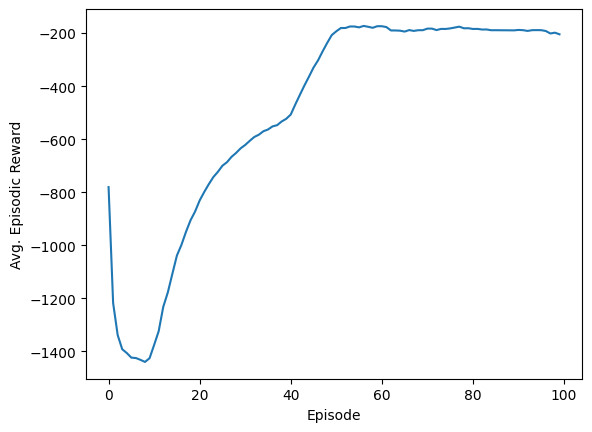

In [5]:
if __name__ == '__main__':
    # Initialize environment and agent
    env = gym.make(ENV_NAME)
    num_states = env.observation_space.shape[0]
    num_actions = env.action_space.shape[0]
    upper_bound = env.action_space.high[0]
    lower_bound = env.action_space.low[0]
    
    agent = DDPGAgent()
    noise = OUActionNoise(mean=np.zeros(1), std_deviation=float(std_dev) * np.ones(1))

    # --- Training Loop ---
    ep_reward_list = []
    avg_reward_list = []

    for ep in range(total_episodes):
        prev_state, _ = env.reset()
        noise.reset()
        episodic_reward = 0

        while True:
            # 1. Get an action
            tf_prev_state = tf.expand_dims(tf.convert_to_tensor(prev_state), 0)
            action = agent.policy(tf_prev_state, noise)
            
            # 2. Interact with environment
            state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            # 3. Store experience
            agent.buffer.record((prev_state, action, reward, state))
            episodic_reward += reward

            # 4. Learn
            if agent.buffer.buffer_counter > batch_size:
                agent.learn()
                agent.update_target_networks()
            
            # 5. Check if episode is over
            if done:
                break
            
            prev_state = state

        ep_reward_list.append(episodic_reward)
        avg_reward = np.mean(ep_reward_list[-40:])
        print(f"Episode {ep} | Avg Reward (last 40): {avg_reward:.2f} | Episodic Reward: {episodic_reward:.2f}")
        avg_reward_list.append(avg_reward)

    # --- Plotting ---
    plt.plot(avg_reward_list)
    plt.xlabel("Episode")
    plt.ylabel("Avg. Episodic Reward")
    plt.show()